### HOUSE PRICE PREDICTION
##### First we selected the problem statement.
##### And next i collected my data set from kaggle
##### Next i installed all python extensions in my vscode.
##### And next python libraries also.
##### I understand my data is classification or regression.
##### Here my data is regression based.
##### And next i start process of ml project 
#### IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [2]:
#### Read the data
df = pd.read_csv("Hyderabad_House_Data.csv")

In [3]:
df .columns

Index(['Unnamed: 0', 'Bedrooms', 'Washrooms', 'Furnishing', 'Tennants', 'Area',
       'Price', 'Locality'],
      dtype='object')

In [4]:
#### For first 5 rows
df.head()

,Unnamed: 0,Bedrooms,Washrooms,Furnishing,Tennants,Area,Price,Locality
0,0,3 BHK Builder Floor,2,Furnished,Bachelors/Family,1800 sqft,"34,000","Bhagyalaxmi Nagar, Kavadiguda"
1,1,3 BHK Apartment,2,Semi-Furnished,Family,2500 sqft,"45,000","Gachibowli, Outer Ring Road"
2,2,1 BHK Builder Floor,Immediately,Furnished,Bachelors/Family,read more,"18,000",Gachibowli
3,3,3 BHK Apartment,Immediately,Furnished,Bachelors/Family,2160 sqft,"40,000","Moosapet, NH"
4,4,3 BHK Apartment,2,Semi-Furnished,Family,1580 sqft,"23,000",Raghavendra Colony kondapur


In [5]:
#### For last 5 rows
df.tail()

,Unnamed: 0,Bedrooms,Washrooms,Furnishing,Tennants,Area,Price,Locality
1166,1166,2 BHK Apartment,1,Unfurnished,Family,900 sqft,"15,000",KPHB Road
1167,1167,1 BHK Apartment,1,Semi-Furnished,Bachelors/Family,East Facing Property,"10,000","Miyapur, NH"
1168,1168,3 BHK Apartment,1,Unfurnished,Bachelors,1515 sqft,"14,000","Pragathi Nagar, Kukatpally"
1169,1169,3 BHK Apartment,From Nov '19,Family,3,1500 sqft,"16,000","Habsiguda, NH"
1170,1170,2 BHK Apartment,2,Semi-Furnished,Bachelors/Family,1100 sqft,"12,000","Umas Aadya and Arha Mensions, Kukatpally, NH"


In [6]:
#### Finding shape for rows & columns
df.shape

(1171, 8)

In [7]:
#### For finding describation
df.describe()

,Unnamed: 0
count,1171.000000
mean,585.000000
std,338.182889
min,0.000000
25%,292.500000
50%,585.000000
75%,877.500000
max,1170.000000


In [8]:
#### For finding null values
df.isnull().sum()

Unnamed: 0     0
Bedrooms       0
Washrooms     21
Furnishing     0
Tennants       1
Area          22
Price          0
Locality       0
dtype: int64

In [9]:
#### For changing columns from catergorical to numeric
df['Washrooms']=pd.to_numeric(df['Washrooms'],errors='coerce')

In [10]:
#### For removing null values
df['Washrooms']=df['Washrooms'].fillna(df['Washrooms'].median())
df.isnull().sum()

Unnamed: 0     0
Bedrooms       0
Washrooms      0
Furnishing     0
Tennants       1
Area          22
Price          0
Locality       0
dtype: int64

In [11]:
#### For changing columns from categorical to numerical
df['Tennants']=pd.to_numeric(df['Tennants'],errors='coerce')

In [12]:
#### For removing null values in Tennants
df['Tennants']=df['Tennants'].fillna(df['Tennants'].median())

df.isnull().sum()

Unnamed: 0     0
Bedrooms       0
Washrooms      0
Furnishing     0
Tennants       0
Area          22
Price          0
Locality       0
dtype: int64

In [13]:
#### For Area
df['Area']=df['Area'].astype(str).str.extract('(\d+)')

df['Area']=pd.to_numeric(df['Area'],errors='coerce')
df['Area']=df['Area'].fillna(df['Area'].median())
df[["Washrooms",'Area']].isnull().sum()
df['Price']=(
    df['Price']
    .astype(str)
    .str.replace(r'[^\d]','',regex=True)
)
df['Price']= df['Price'].astype(float)
df['Price'].dtype
df['Price'].apply(type).value_counts()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Nvija\AppData\Local\Temp\ipykernel_26084\2329535585.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Area']=df['Area'].astype(str).str.extract('(\d+)')


Price
<class 'float'>    1171
Name: count, dtype: int64

In [14]:
#### for checking dependent and independent
x=df.drop('Price',axis=1)
y=df["Price"]
x= pd.get_dummies (x,drop_first=True)

In [15]:
#### for training and testing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x = df.drop('Price', axis=1)
y = df['Price']

x = pd.get_dummies(x, drop_first=True)


In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)


MAE : 5380.8254965378355
MSE : 53398077.5352692
RMSE : 7307.398821418549
R2 Score : 0.5582353072437584
predicted House Price: 22059.542898483352


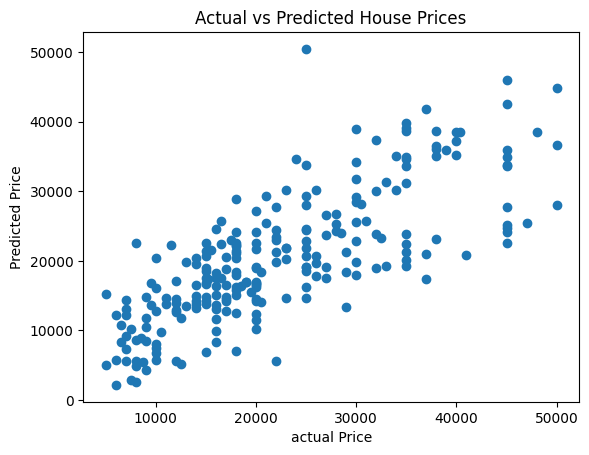

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)
new_house = pd.DataFrame({
    'Area' : [1400],
    'Bedrooms' : [6],
    'Washrooms' : [3]
})

new_house = pd.get_dummies(new_house)
new_house = new_house.reindex(columns=x.columns, fill_value=0)

new_scaled = scaler.transform(new_house)

predicted_price = model.predict(new_scaled)
print("predicted House Price:",predicted_price[0])
plt.scatter(y_test, y_pred)
plt.xlabel("actual Price")
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()
import joblib


In [21]:
new_house = pd.DataFrame({
    'Area': [1400],
    'Bedrooms': [6],
    'Washrooms': [3]
})

new_house = pd.get_dummies(new_house)
new_house = new_house.reindex(columns=x.columns, fill_value=0)

new_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_scaled)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 22059.542898483352


In [22]:
# Save the exact column names from your training data 'x'
model_columns = list(x.columns)
joblib.dump(model_columns, "model_columns.pkl")
print("Model columns saved!")

Model columns saved!


In [23]:
# Save trained model
joblib.dump(model, "house_price_model.pkl")


['house_price_model.pkl']

In [24]:
# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")

# Load model
model = joblib.load("house_price_model.pkl")

Model and Scaler saved successfully!


In [25]:
# Load scaler
scaler = joblib.load("scaler.pkl")